# Instalações de dependências

In [4]:
!pip install nltk seaborn matplotlib pandas

  Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)



[notice] A new release of pip is available: 23.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


# Importação das Bibliotecas




In [ ]:
import pandas as pd
import nltk
from nltk.corpus import stopwords
from nltk.classify import NaiveBayesClassifier
from nltk.tokenize import word_tokenize
import string
import seaborn as sns
import matplotlib.pyplot as plt



In [6]:
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('punkt_tab')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\leona\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\leona\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt.zip.
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\leona\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt_tab.zip.


True

# Carregamento dos Dados

In [9]:
df = pd.read_csv('../data/comentario_label.csv')
df.head(3)

,Comentário,rotulo
0,"Entrega rápida, mas o produto veio danificado.",Negativo
1,Qualidade abaixo do esperado.,negativo
2,"Não gostei, esperava mais.",negativa


# Gerando Gráfico para Compreensão da estrutura dos rótulos

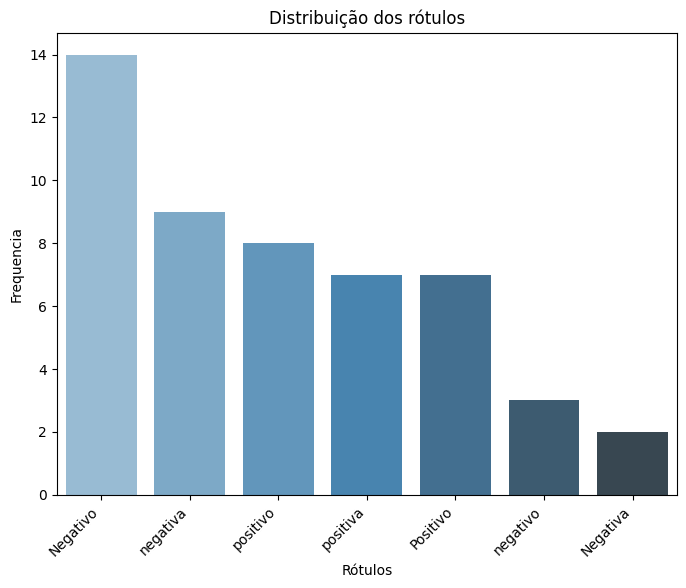

In [10]:
contagem_rotulos = df['rotulo'].value_counts()

# Plotar a distribuição desses rótulos
plt.figure(figsize=(8,6))
sns.barplot(x=contagem_rotulos.index, y=contagem_rotulos.values, palette='Blues_d', hue=contagem_rotulos.index, legend=False)

plt.title("Distribuição dos rótulos")
plt.ylabel("Frequencia")
plt.xlabel("Rótulos")
plt.xticks(rotation=45, ha='right')

plt.show()

# Tratar e Padronizar os rótulos

In [11]:
def padronizar_rotulo(rotulo):
    rotulo = rotulo.lower()
    if rotulo.startswith('negat'):
        return 'negativo'
    elif rotulo.startswith('posit'):
        return 'positivo'
    return rotulo

# Visualizando a Estrutura do Rótulo Após Tratamento

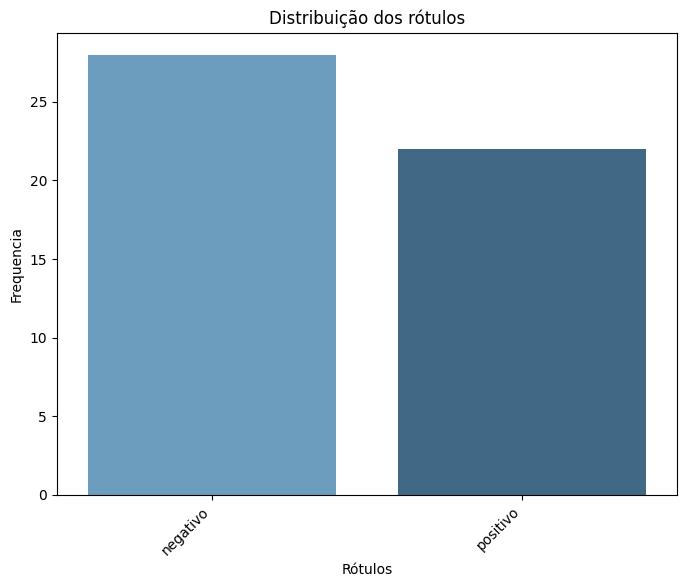

In [13]:
# Padronizar os rótulos
df['rotulo'] = df['rotulo'].apply(padronizar_rotulo)

contagem_rotulos = df['rotulo'].value_counts()

# Plotar a distribuição desses rótulos
plt.figure(figsize=(8,6))
sns.barplot(x=contagem_rotulos.index, y=contagem_rotulos.values, palette='Blues_d', hue=contagem_rotulos.index, legend=False)

plt.title("Distribuição dos rótulos")
plt.ylabel("Frequencia")
plt.xlabel("Rótulos")
plt.xticks(rotation=45, ha='right')

plt.show()

# Preparar os dados para Treinamento

In [16]:
dados_treinamento = [(row['Comentário'], padronizar_rotulo(row['rotulo'])) for index, row in df.iterrows()]
print(f'Número de amostras no conjunto de treinamento: {len(dados_treinamento)}')

Número de amostras no conjunto de treinamento: 50


# Extraindo as features do comentario

O modelo Naive Bayes do NLTK trabalha com um formato de entrada onde:

Cada chave representa uma feature (característica, neste caso uma palavra).

O valor True indica que essa palavra está presente no texto.

Ou seja, o dicionário mostra quais palavras aparecem na frase.

In [17]:
def extrair_features(comentario):
    stops = stopwords.words('portuguese')
    tokens = word_tokenize(comentario.lower())
    palavras_sem_stopwords = [token for token in tokens if token not in stops]
    palavras_sem_pontuacao = [new_token for new_token in palavras_sem_stopwords if new_token not in string.punctuation]
    features = {palavra: True for palavra in palavras_sem_pontuacao}
    return features

# Transformar os dados de treinamento nas features

In [18]:
features_treinamento = [(extrair_features(comentario), rotulo) for (comentario, rotulo) in dados_treinamento]

# Treinamento do Modelo

In [19]:
classificador = NaiveBayesClassifier.train(features_treinamento)

# Salvar Modelo


In [23]:
import joblib
from pathlib import Path
# Caminho para a pasta model
MODEL_PATH = Path("../model/model_sentiment.pkl")
joblib.dump(classificador, MODEL_PATH)
print("Modelo Salvo com sucesso usando Joblib!")

Modelo Salvo com sucesso usando Joblib!


# Analisando o sentimento de novos sentimentos

In [26]:
def analisar_sentimento_nltk(comentarios):
    for comentario in comentarios:
        features = extrair_features(comentario)
        rotulo = classificador.classify(features)
        print(f"\nComentário: {comentario}")
        print(f"Sentimento: {rotulo.upper()}")
        print("-" * 65)

In [27]:
# Testar com novos comentários
comentarios_testes = [
    "Produto excelente, muito satisfeito!",
    "Não gostei do produto, veio com defeito.",
    "É razoável, mas não vale o preço.",
    "Estou muito feliz com a minha compra.",
    "Péssima experiência, não recomendo!",
    "Excelente",
    "Não gostei",
    "Gostei, mas não gostei",
    "Achei sensacional, não poderia ficar sem essa compra"
]

analisar_sentimento_nltk(comentarios_testes)



Comentário: Produto excelente, muito satisfeito!
Sentimento: POSITIVO
-----------------------------------------------------------------

Comentário: Não gostei do produto, veio com defeito.
Sentimento: NEGATIVO
-----------------------------------------------------------------

Comentário: É razoável, mas não vale o preço.
Sentimento: POSITIVO
-----------------------------------------------------------------

Comentário: Estou muito feliz com a minha compra.
Sentimento: NEGATIVO
-----------------------------------------------------------------

Comentário: Péssima experiência, não recomendo!
Sentimento: NEGATIVO
-----------------------------------------------------------------

Comentário: Excelente
Sentimento: POSITIVO
-----------------------------------------------------------------

Comentário: Não gostei
Sentimento: NEGATIVO
-----------------------------------------------------------------

Comentário: Gostei, mas não gostei
Sentimento: NEGATIVO
------------------------------------